# Neural Decoding with Transformers and Hopfield Networks

In this project, we compare Transformer-based models and modern Hopfield-based architectures for neural decoding.

The task is to predict 2D cursor velocity from motor cortex spike activity recorded during a reaching task.

## Setup
We first install required libraries and set up the environment.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
! uv pip install pytorch_brain -q

# We use uv for the installation here, which seems to work better with google colab.
# Although UV is awesome and we highly recommend it, you could install it with vanilla pip
# in your local environments

### Utility Functions

This section defines helper functions used throughout the project for preprocessing, evaluation, and visualization.

Key components include:

- **Data preprocessing**:
  - `bin_spikes`: converts raw spike timestamps into binned neural activity
- **Device handling**:
  - `move_to_gpu`: moves data to GPU/CPU
- **Evaluation metrics**:
  - `r2_score` and `compute_r2`: compute model performance (R² score)
- **Training visualization**:
  - `plot_training_curves`: plots loss and R² over time
- **Model utilities**:
  - `print_model`: displays model structure and parameter count
  - `generate_sinusoidal_position_embs`: creates positional encodings
- **Additional utilities**:
  - `load_pretrained`: loads pretrained weights
  - `get_dataset_config`: prepares dataset configuration

These functions support a modular and reusable training pipeline.

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import warnings
import logging
from torch_brain.utils import seed_everything

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)


def move_to_gpu(data, device):
    """
    Recursively moves tensors (or collections of tensors) to the given device.
    """
    if isinstance(data, torch.Tensor):
        return data.to(device)
    elif isinstance(data, dict):
        return {k: move_to_gpu(v, device) for k, v in data.items()}
    elif isinstance(data, list):
        return [move_to_gpu(elem, device) for elem in data]
    else:
        return data


def bin_spikes(spikes, num_units, bin_size, right=True, num_bins=None):
    """
    Bins spike timestamps into a 2D array: [num_units x num_bins].
    """
    rate = 1 / bin_size  # avoid precision issues
    binned_spikes = np.zeros((num_units, num_bins))
    bin_index = np.floor((spikes.timestamps) * rate).astype(int)
    np.add.at(binned_spikes, (spikes.unit_index, bin_index), 1)
    return binned_spikes


def r2_score(y_pred, y_true):
    # Compute total sum of squares (variance of the true values)
    y_true_mean = torch.mean(y_true, dim=0, keepdim=True)
    ss_total = torch.sum((y_true - y_true_mean) ** 2)

    # Compute residual sum of squares
    ss_res = torch.sum((y_true - y_pred) ** 2)

    # Compute R^2
    r2 = 1 - ss_res / ss_total

    return r2


def compute_r2(dataloader, model):
    # Compute R2 score over the entire dataset
    total_target = []
    total_pred = []
    for batch in dataloader:
        batch = move_to_gpu(batch, device)
        pred = model(**batch["model_inputs"])
        target = batch["target_values"]

        # Store target and pred for visualization
        mask = torch.ones_like(target, dtype=torch.bool)
        if "output_mask" in batch["model_inputs"]:
            mask = batch["model_inputs"]["output_mask"]
        total_target.append(target[mask])
        total_pred.append(pred[mask])

    # Concatenate all batch outputs
    total_target = torch.cat(total_target)
    total_pred = torch.cat(total_pred)

    # Compute the R2 score
    r2 = r2_score(total_pred.flatten(), total_target.flatten())

    return r2.item(), total_target, total_pred


def print_model(model: torch.nn.Module):
    """
    Prints a summary of the model architecture and parameter count.
    """
    model_str = str(model).split('\n')
    print("\nModel:")
    print('\n'.join(model_str[:5]))
    print("...")
    print('\n'.join(model_str[-min(5, len(model_str)):]))
    num_params = sum(p.numel() for p in model.parameters())
    if num_params > 1e9:
        param_str = f"{num_params/1e9:.1f}G"
    elif num_params > 1e6:
        param_str = f"{num_params/1e6:.1f}M"
    else:
        param_str = f"{num_params/1e3:.1f}K"
    print(f"\nNumber of parameters: {param_str}\n")


def plot_training_curves(r2_log, loss_log):
    """
    Plots the training curves: training loss and validation R2 score.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(np.linspace(0, len(loss_log), len(loss_log)), loss_log)
    plt.title("Training Loss")
    plt.xlabel("Training Steps")
    plt.ylabel("MSE Loss")
    plt.grid()
    plt.subplot(1, 2, 2)
    plt.plot(r2_log)
    plt.title("Validation R2")
    plt.xlabel("Epochs")
    plt.ylabel("R2 Score")
    plt.grid()
    plt.tight_layout()
    plt.show()


def generate_sinusoidal_position_embs(num_timesteps, dim):
    position = torch.arange(num_timesteps).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2) * (-np.log(10000.0) / dim))
    pe = torch.empty(num_timesteps, dim)
    pe[:, 0:dim // 2] = torch.sin(position * div_term)
    pe[:, dim//2:] = torch.cos(position * div_term)
    return pe


def load_pretrained(ckpt_path, model):
    print("Loading pretrained model...")
    checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    # poyo is pretrained using lightning, so model weights are prefixed with "model."
    state_dict = {k.replace("model.", ""): v for k, v in checkpoint["state_dict"].items()}
    model.load_state_dict(state_dict)
    print("Done!")
    return model


def reinit_vocab(emb_module, vocab):
    emb_module.extend_vocab(vocab)
    emb_module.subset_vocab(vocab)


def get_dataset_config(brainset, sessions):
    brainset_norms = {
        "perich_miller_population_2018": {
            "mean": 0.0,
            "std": 20.0
        }
    }

    config = f"""
    - selection:
      - brainset: {brainset}
        sessions:"""
    if type(sessions) is not list:
        sessions = [sessions]
    for session in sessions:
        config += f"""
          - {session}"""
    config += f"""
      config:
        readout:
          readout_id: cursor_velocity_2d
          normalize_mean: {brainset_norms[brainset]["mean"]}
          normalize_std: {brainset_norms[brainset]["std"]}
          metrics:
            - metric:
                _target_: torchmetrics.R2Score
    """

    config = OmegaConf.create(config)

    return config

/usr/local/lib/python3.12/dist-packages/temporaldata/temporaldata.py:1209: SyntaxWarning: invalid escape sequence '\*'
  multi-dimensional (2d, 3d, ..., nd) arrays with shape (N, \*).
/usr/local/lib/python3.12/dist-packages/einops/einops.py:737: SyntaxWarning: invalid escape sequence '\s'
  \sum_{c, d, g} x[a, b, c] * y[c, b, d] * z[a, g, k]


### Data Loading and Sampling

In this section, we describe how neural recordings are prepared and sampled for training and evaluation.

We use the `torch_brain` dataset interface, which loads neural recordings and organizes them into training and validation splits.

To handle temporal data efficiently, we apply window-based sampling:

- Each sample corresponds to a fixed **time window (1 second)** of neural activity.
- The continuous recording is split into multiple overlapping or sequential segments.

For training:
- We use a **RandomFixedWindowSampler** to randomly sample time windows.
- This improves generalization by exposing the model to diverse temporal segments.

For validation:
- We use a **SequentialFixedWindowSampler** to ensure deterministic and reproducible evaluation.

The sampled windows are then batched using a DataLoader, which:
- Handles batching
- Applies preprocessing (e.g., tokenization)
- Enables parallel data loading for efficiency

Note: The choice of a 1-second time window defines the temporal context available to the model, directly affecting its ability to capture temporal dependencies.

This pipeline converts continuous neural recordings into structured mini-batches suitable for training sequence models such as Transformers and Hopfield networks.

In [4]:
from torch_brain.data import Dataset, collate, chain
from torch_brain.data.sampler import RandomFixedWindowSampler, SequentialFixedWindowSampler
from torch.utils.data import DataLoader

def get_train_val_loaders(recording_id=None, cfg=None, batch_size=32, seed=0):
    """Sets up train and validation Datasets, Samplers, and DataLoaders
    """

    # -- Train --
    train_dataset = Dataset(
        root="data",                # root directory where .h5 files are found
        recording_id=recording_id,  # you either specify a single recording ID
        config=cfg,                 # or a config for multi-session training / more complex configs
        split="train",
    )
    # We use a random sampler to improve generalization during training
    train_sampling_intervals = train_dataset.get_sampling_intervals()
    train_sampler = RandomFixedWindowSampler(
        sampling_intervals=train_sampling_intervals,
        window_length=1.0,          # context window of samples
        generator=torch.Generator().manual_seed(seed),
    )
    # Finally combine them in a dataloader
    train_loader = DataLoader(
        dataset=train_dataset,      # dataset
        sampler=train_sampler,      # sampler
        batch_size=batch_size,      # num of samples per batch
        collate_fn=collate,         # the collator
        num_workers=4,              # data sample processing (slicing, transforms, tokenization) happens in parallel; this sets the amount of that parallelization
        pin_memory=True,
    )

    # -- Validation --
    val_dataset = Dataset(
        root="data",
        recording_id=recording_id,
        config=cfg,
        split="valid",
    )
    # For validation we don't randomize samples for reproducibility
    val_sampling_intervals = val_dataset.get_sampling_intervals()
    val_sampler = SequentialFixedWindowSampler(
        sampling_intervals=val_sampling_intervals,
        window_length=1.0,
    )
    # Combine them in a dataloader
    val_loader = DataLoader(
        dataset=val_dataset,
        sampler=val_sampler,
        batch_size=batch_size,
        collate_fn=collate,
        num_workers=4,
        pin_memory=True,
    )

    train_dataset.disable_data_leakage_check()
    val_dataset.disable_data_leakage_check()

    return train_dataset, train_loader, val_dataset, val_loader

### Downloading the Dataset

In this step, we download the neural recording used in this project.

The data comes from the Perich & Miller (2018) population dataset, which contains motor cortex recordings from a monkey performing a center-out reaching task.

The dataset is stored as an `.h5` file and includes:
- Neural spike activity from multiple units
- Corresponding behavioral data (cursor velocity)

This file will be used to construct training and validation datasets in the next steps.

In [5]:
! mkdir -p data/perich_miller_population_2018
! gdown 1W--Sm_BcphEC2snoF4zwPdHkkYGgAaUw -O data/perich_miller_population_2018/t_20130819_center_out_reaching.h5

Downloading...
From: https://drive.google.com/uc?id=1W--Sm_BcphEC2snoF4zwPdHkkYGgAaUw
To: /content/data/perich_miller_population_2018/t_20130819_center_out_reaching.h5
100% 9.88M/9.88M [00:00<00:00, 31.4MB/s]


### Training Procedure

In this section, we define the training loop used to optimize the models.

The model is trained using mini-batch gradient descent with the AdamW optimizer. At each epoch:

- The model is first evaluated on the validation set using the R² metric.
- Then, training is performed over batches of data.
- For each batch:
  - A forward pass computes the predicted cursor velocity.
  - The loss is calculated using Mean Squared Error (MSE).
  - Gradients are computed via backpropagation.
  - Model parameters are updated using the optimizer.

We log two key metrics during training:
- **Validation R² score** → measures prediction quality
- **Training loss (MSE)** → measures optimization progress

Additionally, we store model predictions and ground truth values for later analysis and visualization.

This training setup allows us to compare different architectures under identical conditions.

In [8]:
import torch.nn.functional as F

def train(model, optimizer, train_loader, val_loader, num_epochs=50, store_embs=False):
    # We'll store some intermediate outputs for visualization
    train_outputs = {
        'n_epochs': num_epochs,
        'unit_emb': [],
        'session_emb': [],
        'output_pred': [],
        'output_gt': [],
    }

    r2_log = []
    loss_log = []

    # Training loop
    for epoch in range(num_epochs):
        # Compute R² score on validation set
        r2, target, pred = compute_r2(val_loader, model)
        r2_log.append(r2)

        # Training steps
        for batch in train_loader:
            batch = move_to_gpu(batch, device)
            loss = training_step(batch, model, optimizer)
            loss_log.append(loss.item())

        print(f"\rEpoch {epoch+1}/{num_epochs} | Val R2 = {r2:.3f} | Loss = {loss.item():.3f}", end="")

        # Store intermediate outputs
        if store_embs:
            train_outputs['unit_emb'].append(model.unit_emb.weight[1:].detach().cpu().numpy())
            train_outputs['session_emb'].append(model.session_emb.weight[1:].detach().cpu().numpy())
        train_outputs['output_gt'].append(target.detach().cpu().numpy())
        train_outputs['output_pred'].append(pred.detach().cpu().numpy())

    # Compute final R² score
    r2, _, _ = compute_r2(val_loader, model)
    r2_log.append(r2)
    print(f"\nDone! Final validation R2 = {r2:.3f}")

    return r2_log, loss_log, train_outputs


def training_step(batch, model, optimizer):
    optimizer.zero_grad()                  # Step 0. Clear old gradients
    pred = model(**batch["model_inputs"])  # Step 1. Do forward pass
    target = batch["target_values"]
    loss = F.mse_loss(pred, target)        # Step 2. Compute loss
    loss.backward()                        # Step 3. Backward pass
    optimizer.step()                       # Step 4. Update model params
    return loss


# **Training Models**

### Transformer Neural Decoder

This model is a Transformer-based architecture designed to decode neural activity into cursor velocity.

The input to the model is a sequence of binned spike activity with shape:
- **(B, T, N)**  
  - B: batch size  
  - T: number of time steps  
  - N: number of recorded neurons  

#### Model Components

1. **Read-in layer**
   - A linear layer maps neural activity from dimension **N → D**
   - Each timestep becomes a token in the Transformer

2. **Positional encoding**
   - Fixed sinusoidal embeddings are added to preserve temporal order
   - These embeddings are not learned

3. **Transformer layers**
   - The model consists of multiple layers, each containing:
     - Multi-Head Self-Attention (MHA)
     - Feedforward network (FFN)
   - Residual connections are applied after each block

4. **Readout layer**
   - A linear layer maps hidden representations **D → 2**
   - Output corresponds to 2D cursor velocity (vx, vy) at each timestep

#### Key Idea

The Transformer models **temporal dependencies** by learning which time steps are most relevant to each other using self-attention.

This makes it well-suited for neural decoding tasks where behavior depends on temporal patterns in neural activity.

In [9]:
import torch.nn as nn

from torch_brain.nn import FeedForward

class TransformerNeuralDecoder(nn.Module):
    def __init__(
        self, num_units, bin_size, sequence_length,   # data properties
        dim_output, dim_hidden, n_layers, n_heads,    # transformer properties
    ):
        """Initialize the neural net components"""
        super().__init__()

        self.num_timesteps = int(sequence_length / bin_size)
        self.bin_size = bin_size

        # Create the read-in/out linear layers
        self.readin = nn.Linear(num_units, dim_hidden)
        self.readout = nn.Linear(dim_hidden, dim_output)

        # Create the position embeddings
        # Note that these are kept constant in this implementation, i.e. _not_ learnable
        self.position_embeddings = nn.Parameter(
            data=generate_sinusoidal_position_embs(self.num_timesteps, dim_hidden),
            requires_grad=False,
        )

        # Create the transformer layers:
        # each composed of the Attention and the feedforward (FFN) blocks
        self.transformer_layers = nn.ModuleList([
            nn.ModuleList([
                nn.MultiheadAttention(
                    embed_dim=dim_hidden,
                    num_heads=n_heads,
                    batch_first=True,
                ),
                FeedForward(dim=dim_hidden),
            ])
            for _ in range(n_layers)
        ])

    def forward(self, x):
        """Produces predictions from a binned spiketrain.
        This is pure PyTorch code.

        Shape of x: (B, T, N)
        """

        # Read-in: converts our input marix to transformer tokens; one token for each timestep
        x = self.readin(x)  # (B, T, N) -> (B, T, D)

        # Add position embeddings to the tokens
        x = x + self.position_embeddings[None, ...]  # -> (B, T, D)

        # Transformer
        for attn, ffn in self.transformer_layers:
            x = x + attn(x, x, x, need_weights=False)[0]
            x = x + ffn(x)

        # Readout: converts tokens to 2d vectors; each vector signifying (v_x, v_y) at that timestep
        x = self.readout(x)  # (B, T, D) -> (B, T, 2)

        return x

    def tokenize(self, data):
        # Same tokenizer as the MLP

        # A. Bin spikes
        x = bin_spikes(
            spikes=data.spikes,
            num_units=len(data.units),
            bin_size=self.bin_size,
            num_bins=self.num_timesteps,
        ).T

        # B. Extract targets
        y = data.cursor.vel

        data_dict = {
            "model_inputs": {
                "x": torch.tensor(x, dtype=torch.float32),
            },
            "target_values": torch.tensor(y, dtype=torch.float32),
        }
        return data_dict

### Model Training Pipeline

In this section, we train the Transformer-based neural decoder using the prepared dataset.

The training pipeline consists of the following steps:

1. **Dataset setup**
   - We load a neural recording from the Perich & Miller (2018) dataset.
   - Training and validation sets are created using fixed-length temporal windows.

2. **Model initialization**
   - A Transformer-based neural decoder is initialized.
   - The model uses:
     - Hidden dimension: 128
     - Number of layers: 3
     - Number of attention heads: 4
     - Context window: 1 second

3. **Tokenization**
   - The dataset is connected to the model's tokenizer.
   - Raw spike data is converted into binned time-series inputs.

4. **Optimization**
   - The model is trained using the AdamW optimizer.
   - Learning rate is set to 1e-3.

5. **Training**
   - The model is trained for 100 epochs.
   - At each epoch:
     - Validation R² is computed
     - Training loss is minimized using MSE

6. **Evaluation**
   - Training loss and validation R² are tracked over time.
   - These metrics are used to compare model performance.

This setup ensures that all models are trained under identical conditions for a fair comparison.

Epoch 100/100 | Val R2 = 0.683 | Loss = 3.804
Done! Final validation R2 = 0.715


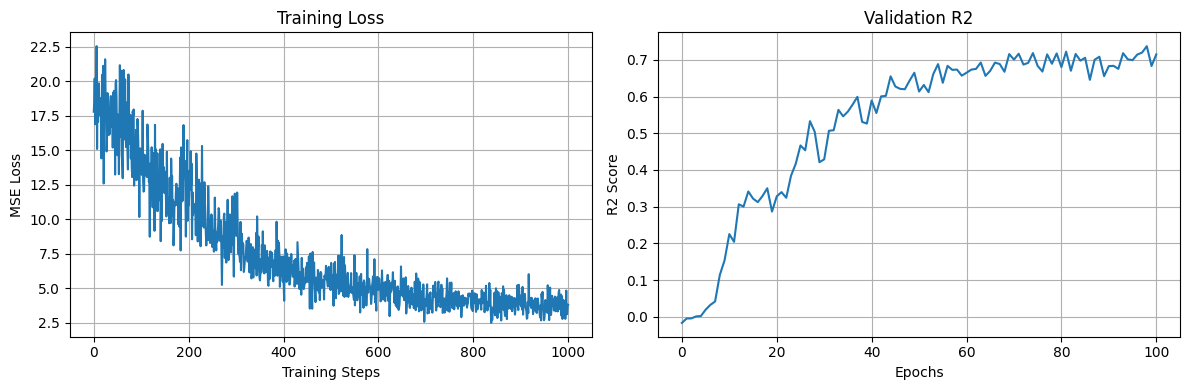

In [10]:
seed_everything(0)

# 1. Setup datasets and dataloader
recording_id = "perich_miller_population_2018/t_20130819_center_out_reaching"
train_dataset, train_loader, val_dataset, val_loader = get_train_val_loaders(recording_id, batch_size=64)
num_units = len(train_dataset.get_unit_ids())

# 2. Initialize Model
tf_model = TransformerNeuralDecoder(
    num_units=num_units,    # Num. of units inputted (spiking activity)
    #
    bin_size=10e-3,         # Duration (s) of bins
    sequence_length=1.0,    # Context length of the model
    #
    dim_output=2,           # Output dimension of final readout layer
    dim_hidden=128,         # Hidden dimension of the model
    n_layers=3,             # Num. of transformer layers
    n_heads=4,              # Num. of heads in MHA blocks
).to(device)

# 3. Connect Tokenizer to Datasets
train_dataset.transform = tf_model.tokenize
val_dataset.transform = tf_model.tokenize

# 4. Setup Optimizer
optimizer = torch.optim.AdamW(tf_model.parameters(), lr=1e-3)

# 5. Train!
transformer_r2_log, transformer_loss_log, transformer_train_outputs = train(tf_model, optimizer, train_loader, val_loader, num_epochs=100)

# Plot the training loss and validation R2
plot_training_curves(transformer_r2_log, transformer_loss_log)

### Saving Training Metrics

In this step, we save the training results for later analysis and visualization.

Since the R² score is computed once per epoch and the training loss is recorded at every training step, their lengths may differ. To ensure consistency, we truncate both logs to the same minimum length.

We then store the following metrics in a CSV file:
- **Epoch index**
- **Validation R² score**
- **Training loss (MSE)**

This allows us to easily visualize and compare model performance using external tools such as Streamlit.

In [11]:
import pandas as pd

min_len = min(len(transformer_r2_log), len(transformer_loss_log))

df = pd.DataFrame({
    "epoch": range(min_len),
    "r2": transformer_r2_log[:min_len],
    "loss": transformer_loss_log[:min_len]
})

df.to_csv("transformer.csv", index=False)

### Installing Hopfield Layers

To implement modern Hopfield networks, we use the official `hopfield-layers` library provided by the authors of the paper.

Since this library is not available on PyPI, it is installed directly from GitHub.

This implementation provides differentiable Hopfield layers that can be integrated into deep learning models, similar to attention mechanisms.

In [12]:
!pip install hflayers


ERROR: Could not find a version that satisfies the requirement hflayers (from versions: none)
ERROR: No matching distribution found for hflayers


In [13]:
!pip install git+https://github.com/ml-jku/hopfield-layers

  Cloning https://github.com/ml-jku/hopfield-layers to /tmp/pip-req-build-6gck6ce8
  Running command git clone --filter=blob:none --quiet https://github.com/ml-jku/hopfield-layers /tmp/pip-req-build-6gck6ce8
  Resolved https://github.com/ml-jku/hopfield-layers to commit f56f929c95b77a070ae675ea4f56b6d54d36e730
  Preparing metadata (setup.py) ... done
  Created wheel for hopfield-layers: filename=hopfield_layers-1.0.2-py3-none-any.whl size=25586 sha256=b0adf67b80b59ea607a813f3ed450b7208124a84f6d9a5a5c1608877b0777d1a
  Stored in directory: /tmp/pip-ephem-wheel-cache-u1wb9m8m/wheels/32/18/8e/6a0676bf7ffad419e7ce03acf68a3b21bde9ba7659199e73f3
Successfully built hopfield-layers


#### Transformer + Hopfield (Hybrid Decoder)

This model extends the standard Transformer by incorporating a modern Hopfield layer.

The architecture follows the same structure as the Transformer, with one key modification:

- A **Hopfield layer is added only at the final layer** of the network.

#### Architecture Overview

1. **Read-in layer**
   - Maps neural activity from dimension **N → D**

2. **Positional encoding**
   - Fixed sinusoidal embeddings preserve temporal order

3. **Transformer layers**
   - Multiple layers of:
     - Multi-Head Self-Attention (MHA)
     - Feedforward network (FFN)

4. **Hopfield layer (last layer only)**
   - Applied after attention in the final layer
   - Performs associative memory retrieval over the sequence

5. **Readout layer**
   - Maps hidden representations **D → 2** (cursor velocity)

#### Key Idea

This model combines:
- **Attention** → learns relationships between timesteps  
- **Hopfield memory** → retrieves stored patterns based on similarity  

By placing the Hopfield layer at the final stage, we test whether adding memory retrieval improves performance after temporal processing.

In [14]:
from hflayers import Hopfield
from torch_brain.nn import FeedForward
import torch.nn as nn

class TransformerHopfieldDecoder(nn.Module):
    def __init__(
        self, num_units, bin_size, sequence_length,
        dim_output, dim_hidden, n_layers, n_heads,
    ):
        super().__init__()

        self.num_timesteps = int(sequence_length / bin_size)
        self.bin_size = bin_size

        # Read-in / Read-out
        self.readin = nn.Linear(num_units, dim_hidden)
        self.readout = nn.Linear(dim_hidden, dim_output)

        # Positional embedding
        self.position_embeddings = nn.Parameter(
            data=generate_sinusoidal_position_embs(self.num_timesteps, dim_hidden),
            requires_grad=False,
        )

        # Transformer layers
        self.transformer_layers = nn.ModuleList([
            nn.ModuleList([
                nn.MultiheadAttention(
                    embed_dim=dim_hidden,
                    num_heads=n_heads,
                    batch_first=True,
                ),
                FeedForward(dim=dim_hidden),
            ])
            for _ in range(n_layers)
        ])

        #  Hopfield layer (Only one)
        self.hopfield = Hopfield(
            input_size=dim_hidden,
            hidden_size=dim_hidden,
            output_size=dim_hidden,
            num_heads=4,
            batch_first=True
        )

    def forward(self, x):

        # Read-in
        x = self.readin(x)

        # Positional encoding
        x = x + self.position_embeddings[None, ...]

        # Transformer + Hopfield
        for i, (attn, ffn) in enumerate(self.transformer_layers):

            x = x + attn(x, x, x, need_weights=False)[0]
            if i == len(self.transformer_layers) - 1: #only last layer
              x = x + self.hopfield(x)

            x = x + ffn(x)

        # Read-out
        x = self.readout(x)

        return x

    def tokenize(self, data):

        x = bin_spikes(
            spikes=data.spikes,
            num_units=len(data.units),
            bin_size=self.bin_size,
            num_bins=self.num_timesteps,
        ).T

        y = data.cursor.vel

        return {
            "model_inputs": {
                "x": torch.tensor(x, dtype=torch.float32),
            },
            "target_values": torch.tensor(y, dtype=torch.float32),
        }

### Training: Transformer + Hopfield Model

In this section, we train the hybrid Transformer + Hopfield model on the neural decoding task.

#### Training Setup

- **Dataset**: Perich & Miller (2018) motor cortex recordings  
- **Task**: Predict 2D cursor velocity from neural spike activity  
- **Batch size**: 64  
- **Sequence length**: 1 second  
- **Bin size**: 10 ms → 100 timesteps per sample  

#### Model Configuration

- Hidden dimension: 128  
- Number of layers: 3  
- Number of attention heads: 4  
- Hopfield layer: applied only at the final layer  

#### Optimization

- Optimizer: AdamW  
- Learning rate: 1e-3  
- Loss function: Mean Squared Error (MSE)  

#### Evaluation

- Metric: R² score on validation set  
- Training duration: 100 epochs  

#### Goal

The goal of this experiment is to evaluate whether adding a Hopfield memory layer on top of a Transformer improves neural decoding performance.

Epoch 100/100 | Val R2 = 0.731 | Loss = 3.272
Done! Final validation R2 = 0.708


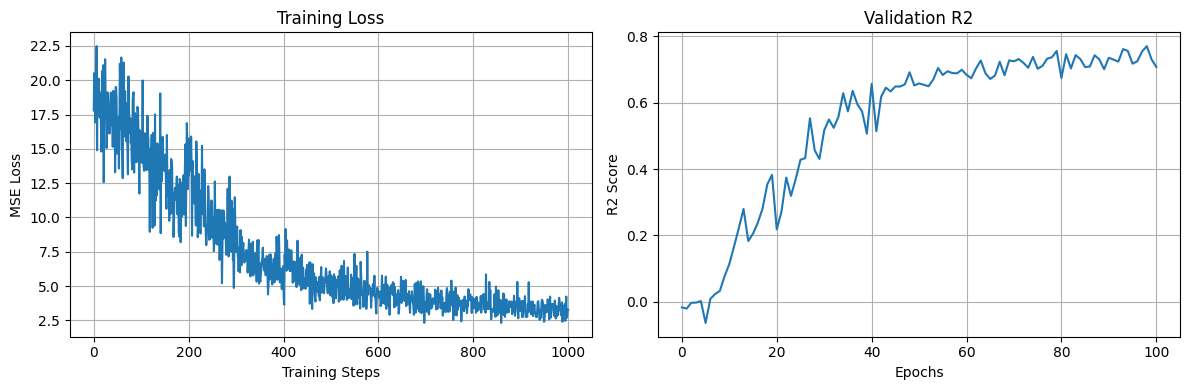

In [15]:
seed_everything(0)

# 1. Setup datasets and dataloader
recording_id = "perich_miller_population_2018/t_20130819_center_out_reaching"
train_dataset, train_loader, val_dataset, val_loader = get_train_val_loaders(
    recording_id, batch_size=64
)

num_units = len(train_dataset.get_unit_ids())

# 2. Initialize Hopfield Transformer Model
hopfield_model = TransformerHopfieldDecoder(
    num_units=num_units,
    bin_size=10e-3,
    sequence_length=1.0,
    dim_output=2,
    dim_hidden=128,
    n_layers=3,
    n_heads=4,
).to(device)

# 3. Connect Tokenizer
train_dataset.transform = hopfield_model.tokenize
val_dataset.transform = hopfield_model.tokenize

# 4. Setup Optimizer
optimizer = torch.optim.AdamW(hopfield_model.parameters(), lr=1e-3)

# 5. Train
hopfield_r2_log, hopfield_loss_log, hopfield_train_outputs = train(
    hopfield_model,
    optimizer,
    train_loader,
    val_loader,
    num_epochs=100
)

# 6. Plot
plot_training_curves(hopfield_r2_log, hopfield_loss_log)

### Saving Training Metrics

In this step, we save the training results for later analysis and visualization.

Since the R² score is computed once per epoch and the training loss is recorded at every training step, their lengths may differ.

We store the metrics directly as recorded during training in a CSV file:

- Epoch index  
- Validation R² score  
- Training loss (MSE)  

This allows us to easily visualize and compare model performance using external tools such as Streamlit.

In [19]:
min_len = min(len(hopfield_r2_log), len(hopfield_loss_log))

df = pd.DataFrame({
    "epoch": range(min_len),
    "r2": hopfield_r2_log[:min_len],
    "loss": hopfield_loss_log[:min_len]
})

df.to_csv("t_hop_last.csv", index=False)

### Hopfield-Only Neural Decoder

This model replaces Transformer self-attention entirely with Hopfield layers.

The goal is to evaluate whether associative memory mechanisms alone are sufficient for neural decoding.

#### Input Representation

The input to the model is a sequence of binned spike activity with shape:

- **(B, T, N)**  
  - B: batch size  
  - T: number of time steps  
  - N: number of recorded neurons  

#### Model Components

1. **Read-in layer**
   - A linear layer maps neural activity from dimension **N → D**
   - Each timestep becomes a token representation

2. **Position encoding**
   - Fixed sinusoidal embeddings are added
   - This provides temporal order information

3. **Hopfield layers**
   - Each layer replaces self-attention with a Hopfield update
   - The model retrieves patterns based on similarity (associative memory)
   - Each block consists of:
     - Hopfield layer
     - Feedforward network (FFN)
   - Residual connections are applied after each block

4. **Readout layer**
   - A linear layer maps hidden representations **D → 2**
   - Output corresponds to cursor velocity (vx, vy)

#### Key Idea

Unlike Transformers, which explicitly model temporal dependencies, this model relies on **associative memory retrieval**.

It tests whether neural activity can be decoded by recalling learned patterns rather than attending over time.

In [20]:
from hflayers import Hopfield
from torch_brain.nn import FeedForward
import torch
import torch.nn as nn

class HopfieldOnlyDecoder(nn.Module):
    def __init__(
        self, num_units, bin_size, sequence_length,
        dim_output, dim_hidden, n_layers
    ):
        super().__init__()

        self.num_timesteps = int(sequence_length / bin_size)
        self.bin_size = bin_size

        # Read-in / Read-out
        self.readin = nn.Linear(num_units, dim_hidden)
        self.readout = nn.Linear(dim_hidden, dim_output)

        # Position embeddings
        self.position_embeddings = nn.Parameter(
            generate_sinusoidal_position_embs(self.num_timesteps, dim_hidden),
            requires_grad=False
        )

        # Hopfield layers
        self.layers = nn.ModuleList([
            nn.ModuleList([
                Hopfield(
                    input_size=dim_hidden,
                    hidden_size=dim_hidden,
                    output_size=dim_hidden,
                    num_heads=4,
                    batch_first=True
                ),
                FeedForward(dim=dim_hidden)
            ])
            for _ in range(n_layers)
        ])

    def forward(self, x):
        # (B, T, N) → (B, T, D)
        x = self.readin(x)

        # + position
        x = x + self.position_embeddings[None, ...]

        # Hopfield blocks
        for hopfield, ffn in self.layers:
            x = x + hopfield(x)   # hopfield instead of attention
            x = x + ffn(x)

        # output
        x = self.readout(x)
        return x

    def tokenize(self, data):
        x = bin_spikes(
            spikes=data.spikes,
            num_units=len(data.units),
            bin_size=self.bin_size,
            num_bins=self.num_timesteps,
        ).T

        y = data.cursor.vel

        return {
            "model_inputs": {
                "x": torch.tensor(x, dtype=torch.float32),
            },
            "target_values": torch.tensor(y, dtype=torch.float32),
        }

### Training: Hopfield-Only Model

In this section, we train the Hopfield-only model on the neural decoding task.

#### Training Setup

- **Dataset**: Perich & Miller (2018) motor cortex recordings  
- **Task**: Predict 2D cursor velocity from neural spike activity  
- **Batch size**: 64  
- **Sequence length**: 1 second  
- **Bin size**: 10 ms → 100 timesteps per sample  

#### Model Configuration

- Hidden dimension: 128  
- Number of layers: 3  
- Architecture: Hopfield layers only (no attention)  

#### Optimization

- Optimizer: AdamW  
- Learning rate: 1e-3  
- Loss function: Mean Squared Error (MSE)  

#### Evaluation

- Metric: R² score on validation set  
- Training duration: 100 epochs  

#### Goal

The goal of this experiment is to evaluate whether associative memory alone can solve the neural decoding task, without relying on attention mechanisms.

All training conditions are kept identical to the Transformer and hybrid models to ensure a fair comparison.

Epoch 100/100 | Val R2 = 0.745 | Loss = 3.435
Done! Final validation R2 = 0.711


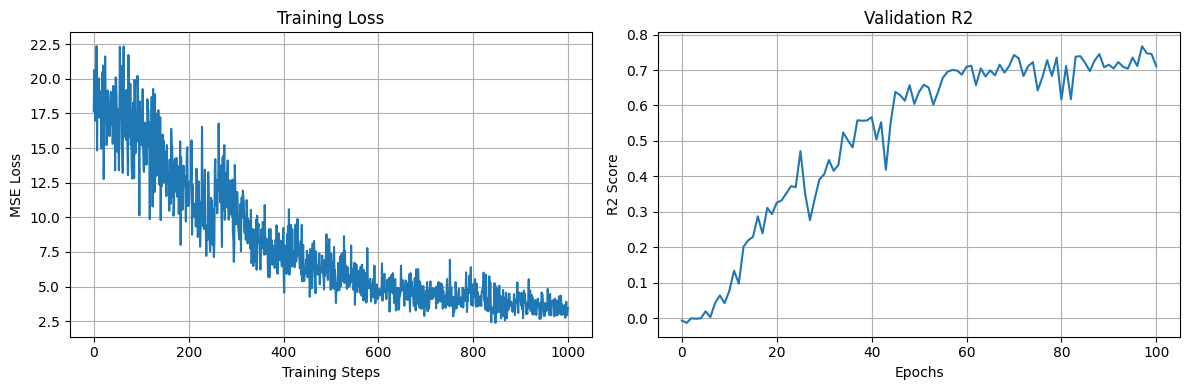

In [21]:
seed_everything(0)

recording_id = "perich_miller_population_2018/t_20130819_center_out_reaching"
train_dataset, train_loader, val_dataset, val_loader = get_train_val_loaders(
    recording_id, batch_size=64
)

num_units = len(train_dataset.get_unit_ids())

hopfield_only_model = HopfieldOnlyDecoder(
    num_units=num_units,
    bin_size=10e-3,
    sequence_length=1.0,
    dim_output=2,
    dim_hidden=128,
    n_layers=3,
).to(device)

train_dataset.transform = hopfield_only_model.tokenize
val_dataset.transform = hopfield_only_model.tokenize

optimizer = torch.optim.AdamW(hopfield_only_model.parameters(), lr=1e-3)

hopfield_only_r2_log, hopfield_only_loss_log, _ = train(
    hopfield_only_model,
    optimizer,
    train_loader,
    val_loader,
    num_epochs=100
)

plot_training_curves(hopfield_only_r2_log, hopfield_only_loss_log)

### Saving Training Metrics

In this step, we save the training results for later analysis and visualization.

Since the R² score is computed once per epoch and the training loss is recorded at every training step, their lengths may differ.

We store the metrics directly as recorded during training in a CSV file:

- Epoch index  
- Validation R² score  
- Training loss (MSE)  

This allows us to easily visualize and compare model performance using external tools such as Streamlit.

In [23]:
import pandas as pd

min_len = min(len(hopfield_only_r2_log), len(hopfield_only_loss_log))

df = pd.DataFrame({
    "epoch": range(min_len),
    "r2": hopfield_only_r2_log[:min_len],
    "loss": hopfield_only_loss_log[:min_len]
})

df.to_csv("hopfield.csv", index=False)

### Saving Trained Models

In this step, we save the trained model weights for future use.

Each model's parameters are stored using `torch.save`, allowing us to:

- Reload models without retraining  
- Perform further analysis or evaluation  
- Deploy models in other applications  

All models are saved to a designated directory for organized storage.

In [ ]:
import torch
import os

os.makedirs("/content/drive/MyDrive/saved_models", exist_ok=True)

torch.save(mlp_model.state_dict(),           "/content/drive/MyDrive/saved_models/mlp_model.pth")
torch.save(tf_model.state_dict(),            "/content/drive/MyDrive/saved_models/transformer_model.pth")
torch.save(hopfield_model.state_dict(),      "/content/drive/MyDrive/saved_models/transformer_hopfield_model.pth")
torch.save(hopfield_only_model.state_dict(), "/content/drive/MyDrive/saved_models/hopfield_only_model.pth")

print("Models are saved!")

### Comparing Model Performance

In this step, we visualize the validation performance of all models.

We automatically collect all stored R² logs and plot them on the same graph.

This allows us to:

- Compare convergence behavior across models  
- Analyze learning dynamics over epochs  
- Identify which model performs best  

Each curve represents the validation R² score over training epochs for a different model.

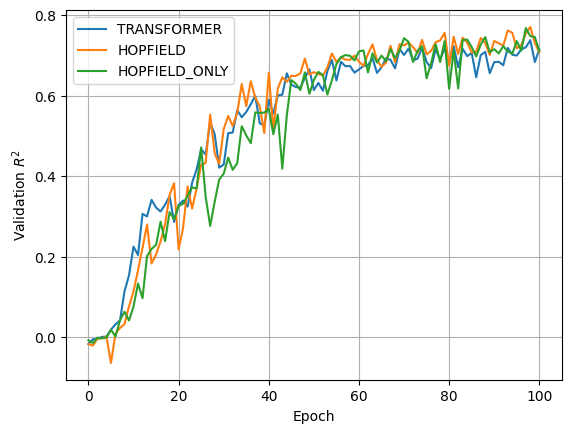

In [24]:
lcls = locals().copy()
for lcl in lcls:
    if not lcl.endswith("_r2_log"):
        continue
    model = lcl.split("_r2_log")[0].upper()
    plt.plot(locals()[lcl], label=model)
plt.xlabel("Epoch")
plt.ylabel("Validation $R^2$")
plt.grid()
plt.legend()
plt.show()